## Importing nessecary modules
#1. Make sure you have the necessary modules and data.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from sklearn.datasets import make_moons, make_blobs, make_circles
from sklearn.preprocessing import StandardScaler

## Prepare the datasets 
#2. Prepare the datasets for the plots. We do this by generating the datasets according to the hyperparameters specified in the instructions and by standardizing to make sure the clustering algorithm is treating all features equally. Additionally, for reproducability I have decided to add the hyperparameter random_state=46 because this ensures that each time we run the code we will get the same random dataset. This specific dataset 46 I found works well with what I want to portray.

In [13]:
# Generate datasets
X_moons, _ = make_moons(n_samples=300, noise=0.05,random_state=46)
X_blobs, _ = make_blobs(n_samples=300, centers=3, cluster_std=[1.0, 2.5, 0.5], random_state=46)
X_circles, _ = make_circles(n_samples=300, factor=0.5, noise=0.05, random_state=46)


# Standardize datasets
X_moons = StandardScaler().fit_transform(X_moons)
X_blobs = StandardScaler().fit_transform(X_blobs)
X_circles = StandardScaler().fit_transform(X_circles)



## Define the algorithms
#3. We define the clustering algorithms and set the proper hyperparameters. In this case DBSCAN is finding clusters based on density with eps radius=0.3 and min_samples=5. This means a radius of a point must contain 5 points to be considered a core point. K-means will create 2 clusters from the data because I am predefining k=2. Hierarchical clustering will group points based on the predetermined n_clusters=2 with a bottom-up approach. All the hyperparameters can be fine tuned based on what you want. I am using arbitrary values that I beleive will work well with my data based on research and experimentation.

In [14]:
# Define clustering algorithms
clustering_algorithms = {
    "DBSCAN": DBSCAN(eps=0.3, min_samples=5),
    "K-Means": KMeans(n_clusters=2),
    "Hierarchical": AgglomerativeClustering(n_clusters=2)
}


## Create a function for the plots 
#4. A function was created to make aesthetic plots.

In [15]:
# Function to plot results
# The function will create 3 subplots for each clustering method.
def plot_clusters(X, title, clustering_algorithms):
    fig, ii = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(title, fontsize=18)

    # Below is the loop to loop through the clustering algorithms
    # In this case clustering_algorithms.items() is a dictionary containing the algorithm information and zip pairs each subplot i with an algorithm.
    # For each iteration the algorithm information will be unpacked, and clustering plus plot specifications will be applied.
    for i, (name, algorithm) in zip(ii, clustering_algorithms.items()):
        labels = algorithm.fit_predict(X)
        i.scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis", edgecolor="k", s=50)
        i.set_title(name)
        i.set_xticks([])
        i.set_yticks([])

    plt.show()

## Final Plots 
#5. Show the plots

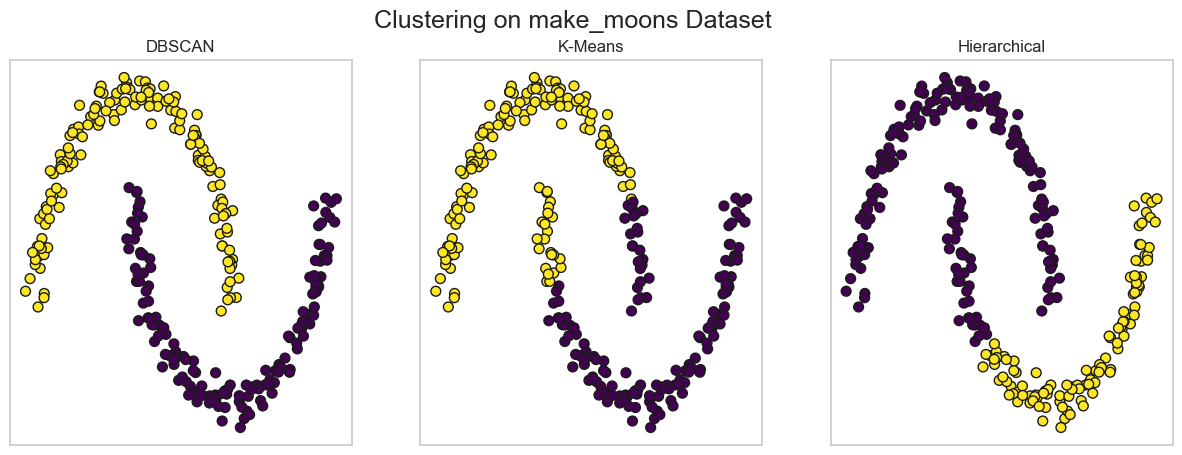

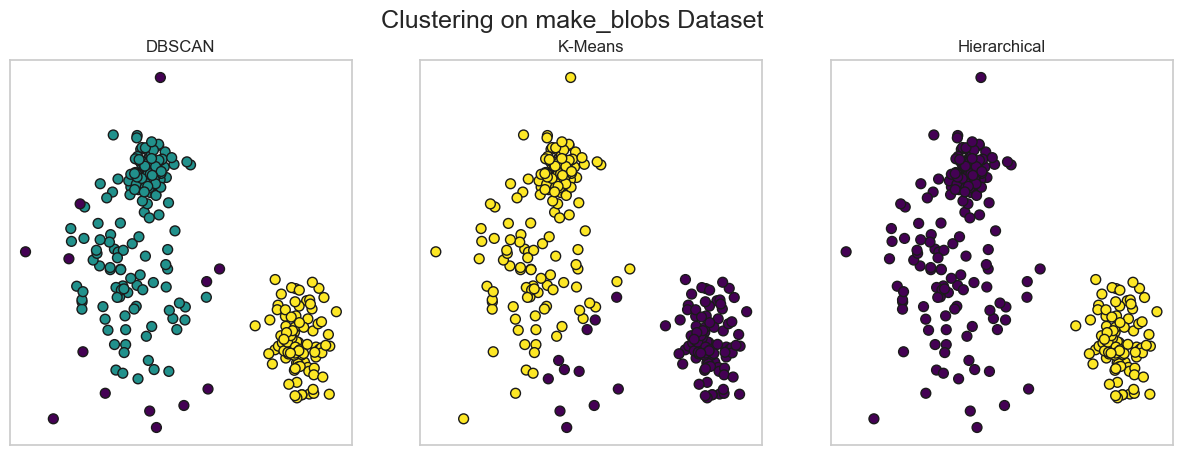

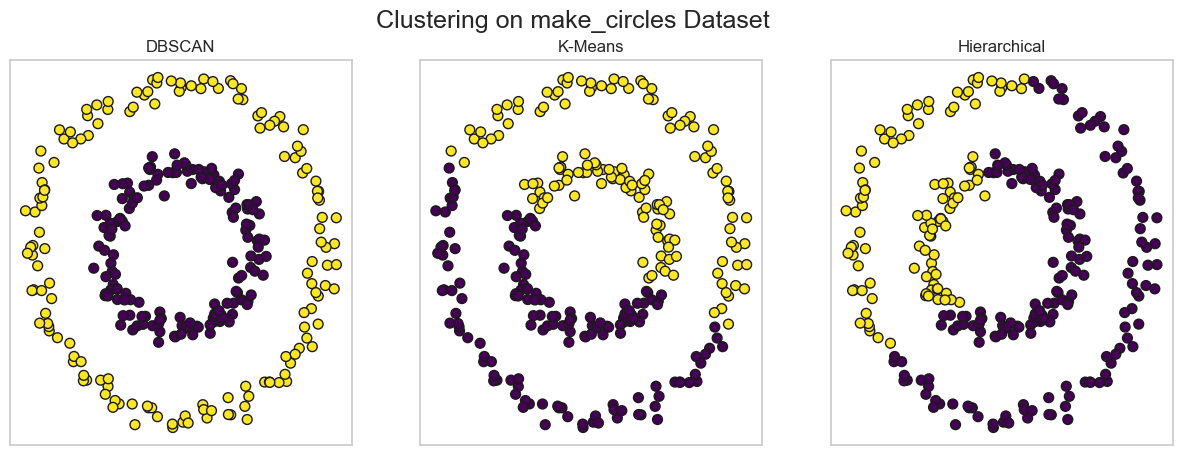

In [16]:
# Plot clustering results
plot_clusters(X_moons, "Clustering on make_moons Dataset", clustering_algorithms)
plot_clusters(X_blobs, "Clustering on make_blobs Dataset", clustering_algorithms)
plot_clusters(X_circles, "Clustering on make_circles Dataset", clustering_algorithms)